# Анализ метрик проведенных экспериментов

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import os

In [2]:
def plot_confusion_matrix(cm, labels, title="", figsize=(7, 6), normalize=True):
    cm = np.asarray(cm, dtype=float)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, where=row_sums != 0)

    if normalize:
        data = cm_norm
        annot = np.array([
            [f"{int(count)}\n{share:.2f}" for count, share in zip(row, nrow)]
            for row, nrow in zip(cm, cm_norm)
        ])
        fmt = "s"
        cbar_label = "Доля (по строке)"
        vmin, vmax = 0.0, 1.0
    else:
        data = cm
        annot = True
        fmt = ".0f"
        cbar_label = "Количество"
        vmin, vmax = None, None

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        data,
        annot=annot,
        fmt=fmt,
        xticklabels=labels,
        yticklabels=labels,
        cmap="Blues",
        square=True,
        vmin=vmin,
        vmax=vmax,
        cbar_kws={"label": cbar_label},
        ax=ax,
    )
    ax.set_xlabel("Предсказанный класс")
    ax.set_ylabel("Истинный класс")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

In [3]:
def get_experiment_results(run_name: str):
    results_path = Path(f"../logs/{run_name}")
    print(f'Experiment: {run_name}')
    metrics = pd.read_csv(results_path / 'metrics.csv')
    with open(results_path / 'summary.json') as f:
        summary = json.load(f)
    output_df = {}
    if 'train' in summary['results'].keys():
        output_df['train'] = [
            summary['results']['train']['loss'],
            summary['results']['train']['patch']['accuracy'],
            summary['results']['train']['patch']['precision'],
            summary['results']['train']['patch']['recall'],
            summary['results']['train']['patch']['f1']
        ]
    output_df['val'] = [
        summary['results']['val']['loss'],
        summary['results']['val']['patch']['accuracy'],
        summary['results']['val']['patch']['precision'],
        summary['results']['val']['patch']['recall'],
        summary['results']['val']['patch']['f1']
    ]
    output_df['test'] = [
        summary['results']['test']['loss'],
        summary['results']['test']['patch']['accuracy'],
        summary['results']['test']['patch']['precision'],
        summary['results']['test']['patch']['recall'],
        summary['results']['test']['patch']['f1']
    ]
    output_df = pd.DataFrame(output_df, index=['loss', 'accuracy', 'precision', 'recall', 'f1'])
    print(output_df)

    if 'train_patch_accuracy' in metrics.columns:
        plt.title('Accuracy')
        sns.lineplot(x='epoch', y='train_patch_accuracy', data=metrics, label='train')
        sns.lineplot(x='epoch', y='val_patch_accuracy', data=metrics, label='val')
        plt.ylabel('accuracy')
        plt.show()

        plt.title('F1')
        sns.lineplot(x='epoch', y='train_patch_f1', data=metrics, label='train')
        sns.lineplot(x='epoch', y='val_patch_f1', data=metrics, label='val')
        plt.ylabel('F1')
        plt.show()

    elif 'train_eval_patch_accuracy' in metrics.columns:
        plt.title('Accuracy')
        sns.lineplot(x='epoch', y='train_eval_patch_accuracy', data=metrics, label='train')
        sns.lineplot(x='epoch', y='val_patch_accuracy', data=metrics, label='val')
        plt.ylabel('accuracy')
        plt.show()

        plt.title('F1')
        sns.lineplot(x='epoch', y='train_eval_patch_f1', data=metrics, label='train')
        sns.lineplot(x='epoch', y='val_patch_f1', data=metrics, label='val')
        plt.ylabel('F1')
        plt.show()

    else:
        plt.title('Accuracy')
        sns.lineplot(x='epoch', y='val_patch_accuracy', data=metrics, label='val')
        plt.ylabel('accuracy')
        plt.show()

        plt.title('F1')
        sns.lineplot(x='epoch', y='val_patch_f1', data=metrics, label='val')
        plt.ylabel('F1')
        plt.show()

    class_names = summary['class_names']
    plot_confusion_matrix(
        summary['results']['test']['patch']['confusion_matrix'],
        labels=class_names,
        title=f"{run_name}",
    )

## Общие метрики

Experiment: fastvit_t8_patches_all_patches_new_dataset_20260917_102921
              train       val      test
loss       0.923355  1.484462  1.514549
accuracy   0.712834  0.464264  0.489958
precision  0.708489  0.430767  0.495577
recall     0.688266  0.451677  0.493989
f1         0.692069  0.417700  0.458142


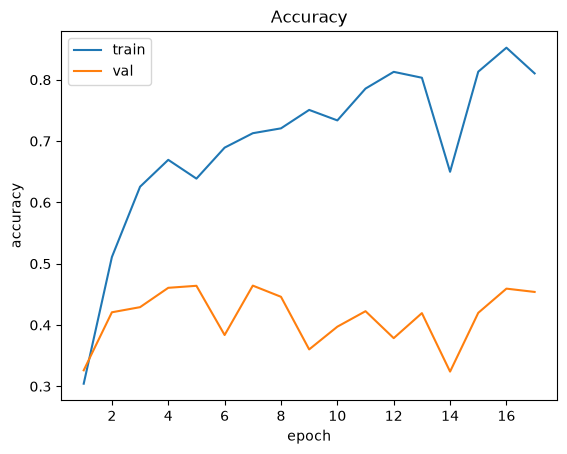

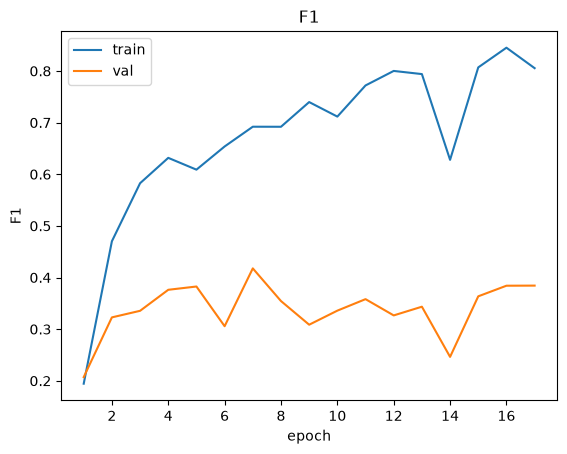

/tmp/ipykernel_26514/3840804484.py:4: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  cm_norm = np.divide(cm, row_sums, where=row_sums != 0)


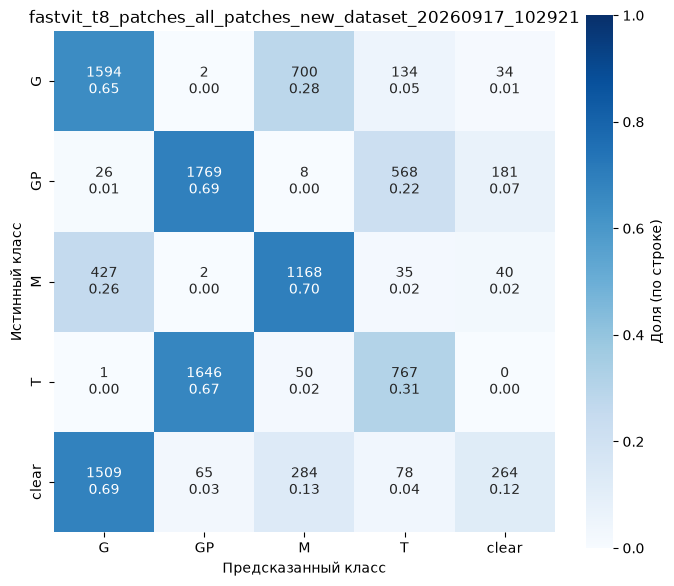

Experiment: fastvit_t8_patches_20260917_091605
                val      test
loss       1.208139  1.210160
accuracy   0.557410  0.534091
precision  0.540848  0.522064
recall     0.523755  0.505475
f1         0.520595  0.499951


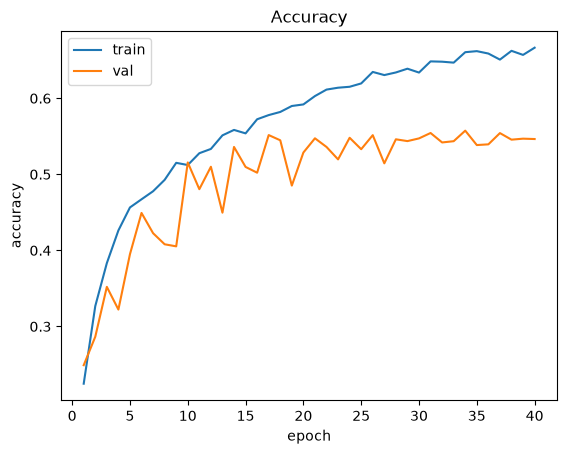

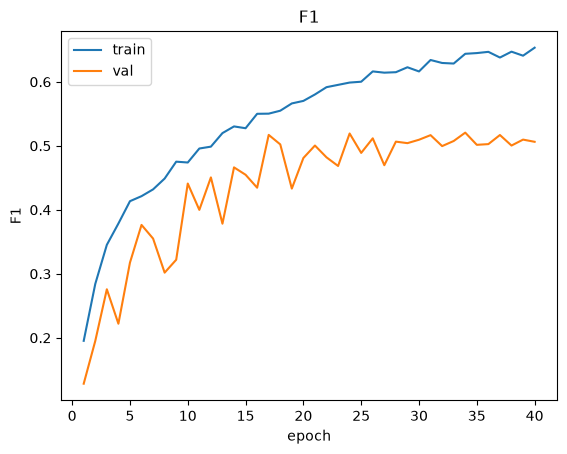

/tmp/ipykernel_26514/3840804484.py:4: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  cm_norm = np.divide(cm, row_sums, where=row_sums != 0)


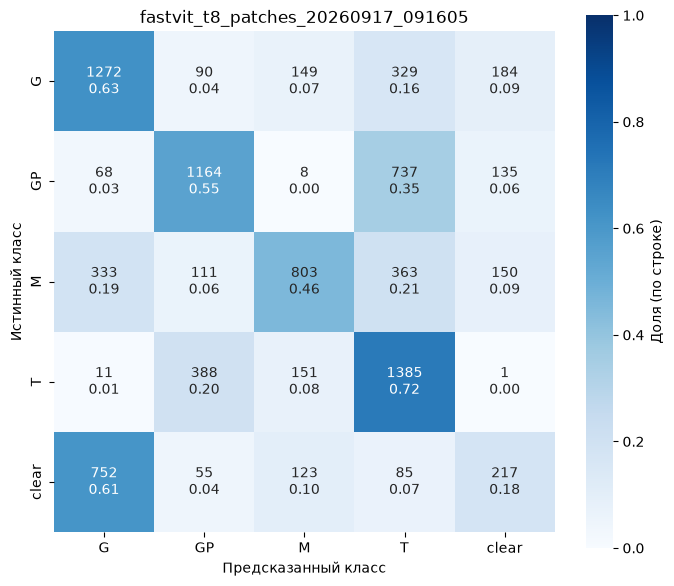

Experiment: abl_no_blur_20260917_162558
              train       val      test
loss       0.610647  1.115135  1.091932
accuracy   0.884341  0.656723  0.660305
precision  0.884291  0.638828  0.657142
recall     0.881701  0.632503  0.651109
f1         0.882406  0.632631  0.650320


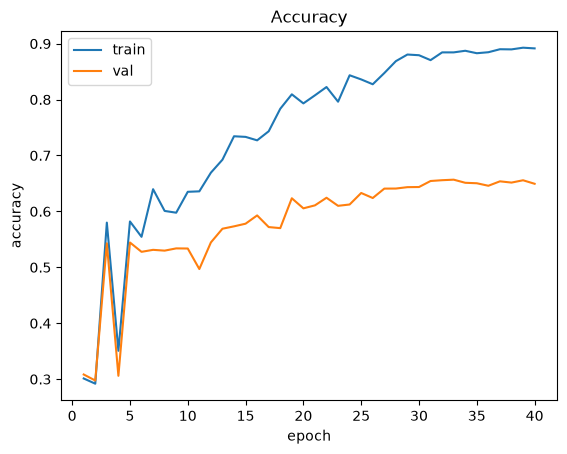

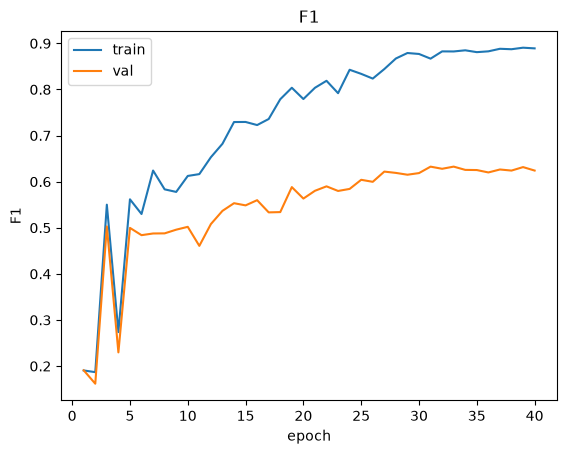

/tmp/ipykernel_26514/3840804484.py:4: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  cm_norm = np.divide(cm, row_sums, where=row_sums != 0)


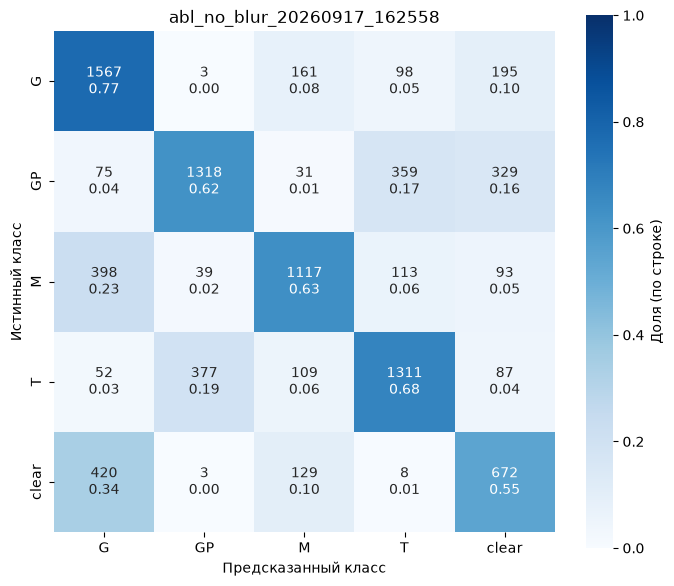

Experiment: abl_overlap_train05_eval05_20260917_150147
Experiment: fastvit_t8_patches_new_dataset_20260917_093808
              train       val      test
loss       1.095695  1.404628  1.473965
accuracy   0.613029  0.450060  0.465469
precision  0.603783  0.364549  0.494475
recall     0.573089  0.382314  0.474111
f1         0.562670  0.365512  0.425038


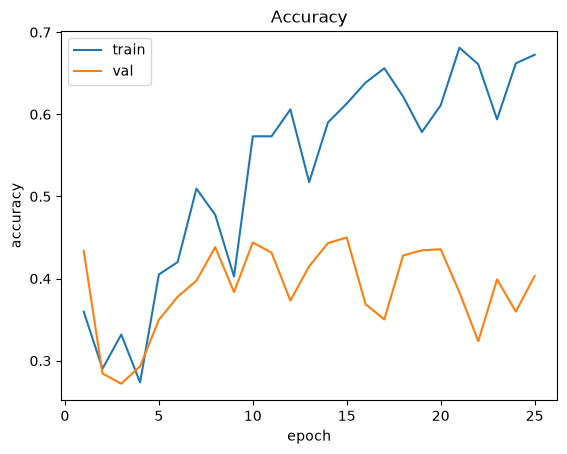

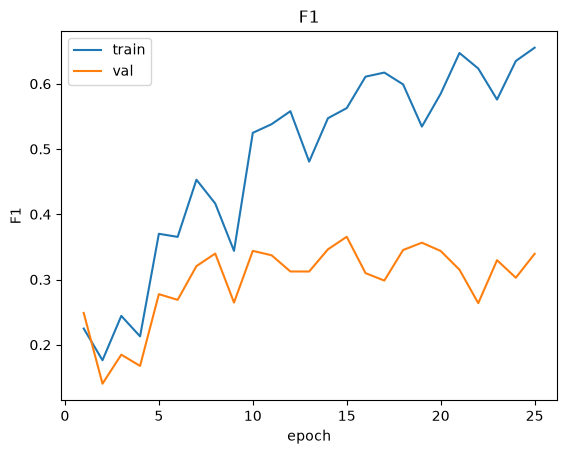

/tmp/ipykernel_26514/3840804484.py:4: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  cm_norm = np.divide(cm, row_sums, where=row_sums != 0)


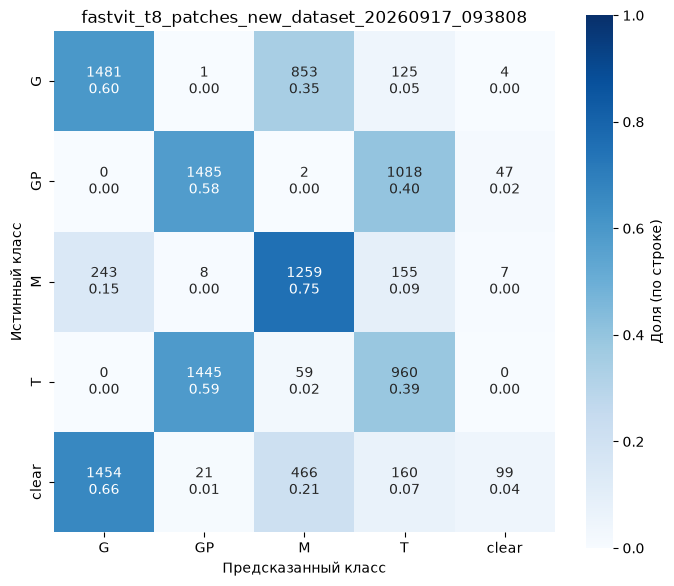

Experiment: abl_overlap_train05_20260917_112844
              train       val      test
loss       0.424416  1.159672  1.160772
accuracy   0.984478  0.672585  0.666152
precision  0.984865  0.658173  0.667468
recall     0.984060  0.649178  0.653466
f1         0.984451  0.651905  0.654164


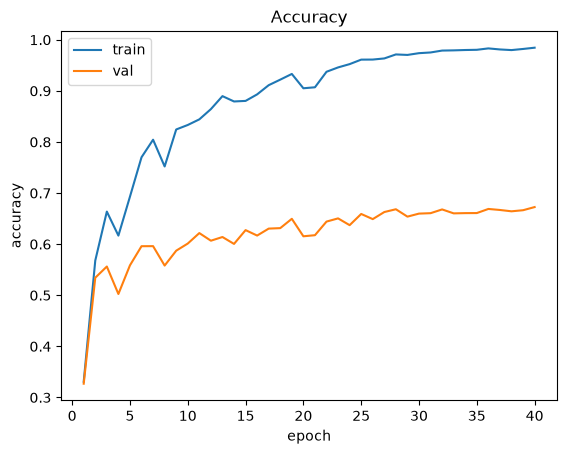

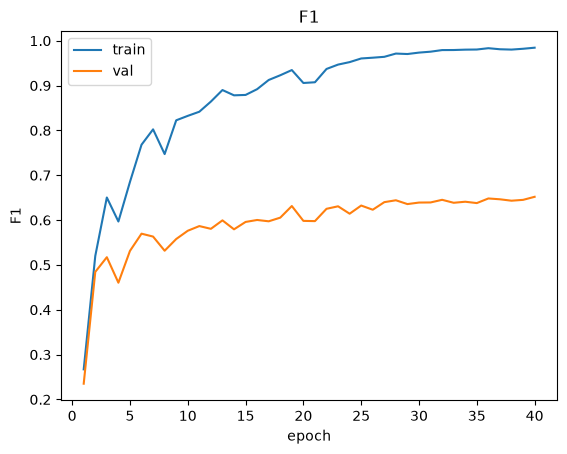

/tmp/ipykernel_26514/3840804484.py:4: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  cm_norm = np.divide(cm, row_sums, where=row_sums != 0)


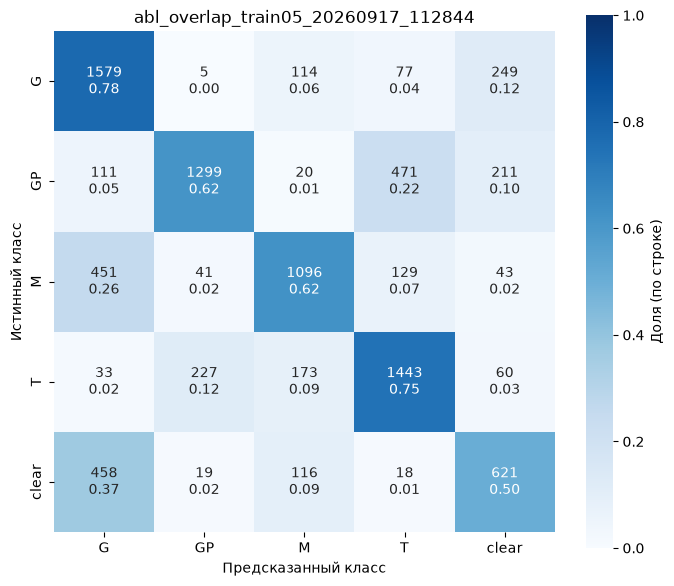

Experiment: abl_class_w_20260917_173339
              train       val      test
loss       0.936500  1.170953  1.178299
accuracy   0.712225  0.610914  0.596425
precision  0.714388  0.604739  0.591124
recall     0.699612  0.590570  0.577865
f1         0.703621  0.592185  0.578128


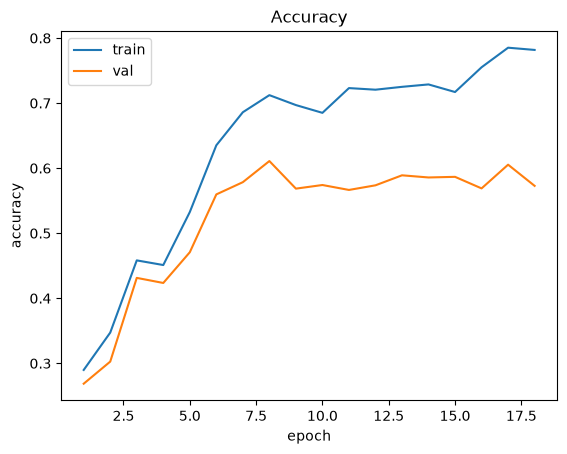

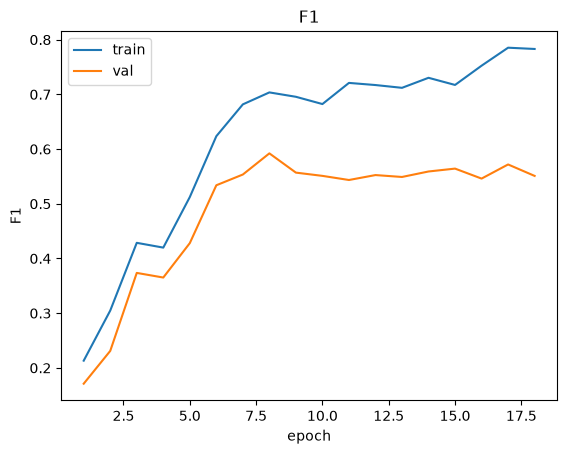

/tmp/ipykernel_26514/3840804484.py:4: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  cm_norm = np.divide(cm, row_sums, where=row_sums != 0)


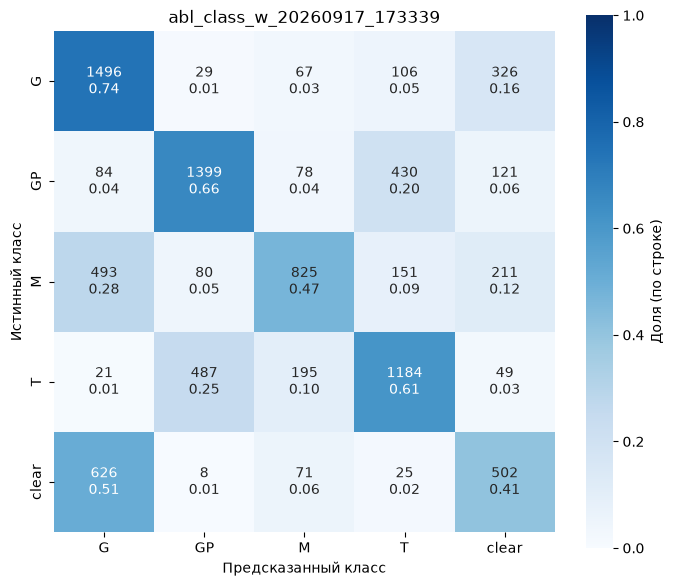

Experiment: no_augmentations_20260917_180531
              train       val      test
loss       0.430297  1.181707  1.218466
accuracy   0.985302  0.679451  0.643535
precision  0.982986  0.665402  0.649813
recall     0.985709  0.659847  0.644231
f1         0.984268  0.660781  0.639137


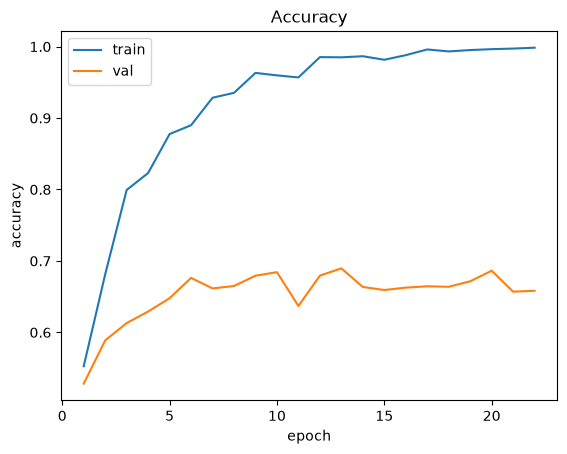

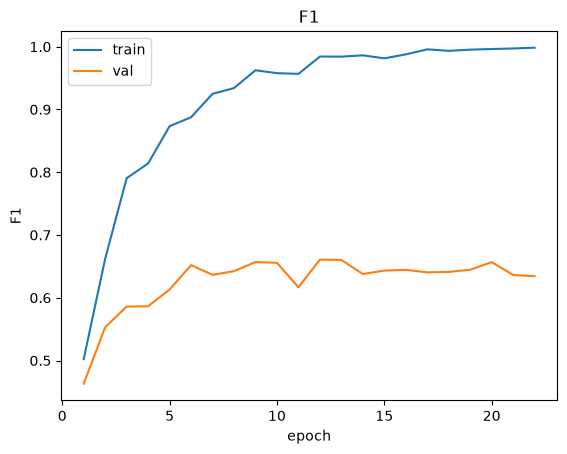

/tmp/ipykernel_26514/3840804484.py:4: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  cm_norm = np.divide(cm, row_sums, where=row_sums != 0)


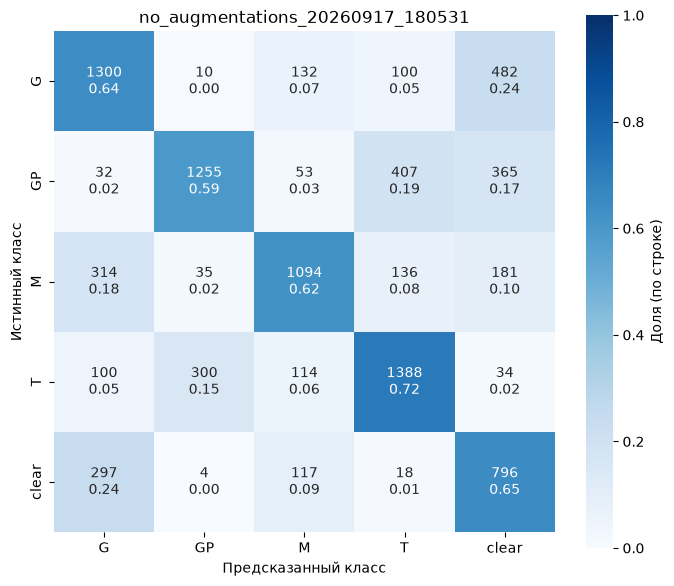

Experiment: fastvit_t8_patches_all_patches_20260917_095725
              train       val      test
loss       0.897318  1.162150  1.116262
accuracy   0.727747  0.613636  0.615843
precision  0.741829  0.600044  0.613916
recall     0.703950  0.582305  0.586936
f1         0.711823  0.582797  0.585804


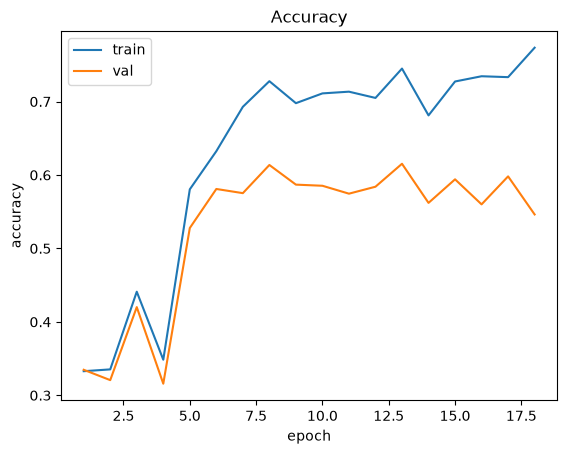

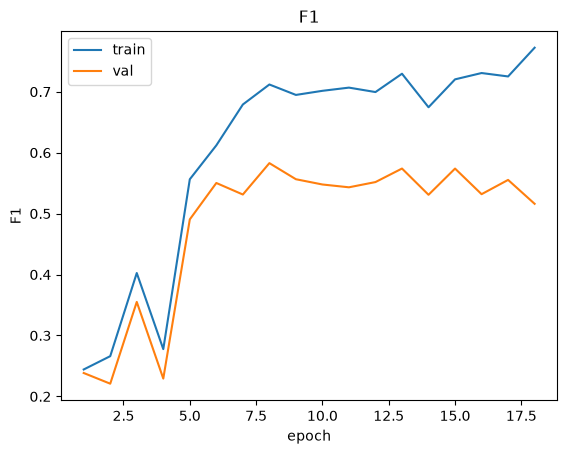

/tmp/ipykernel_26514/3840804484.py:4: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  cm_norm = np.divide(cm, row_sums, where=row_sums != 0)


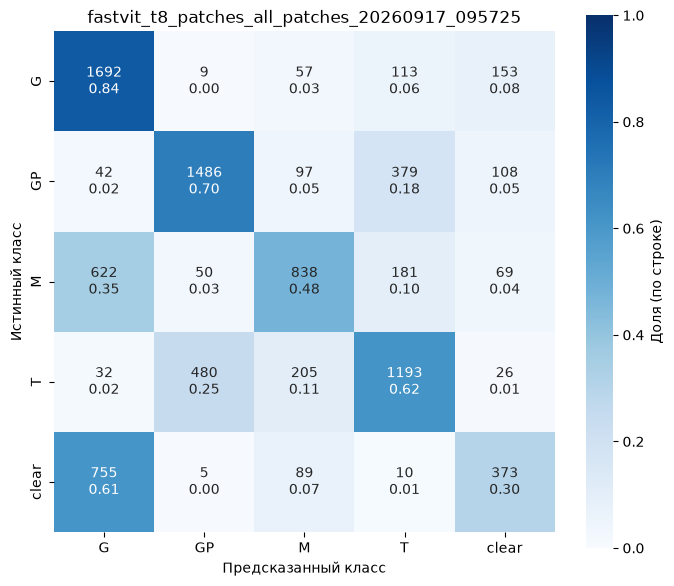

In [5]:
for rname in os.listdir('../logs'):
    try:
        get_experiment_results(rname)
    except Exception as e:
        pass

## Accuracy и F1 по экспериментам

In [11]:
runs = []
accs = []
f1s = []
for rname in os.listdir('../logs'):
    if 'summary.json' in os.listdir(f'../logs/{rname}'):
        runs.append(rname)
        with open(Path(f'../logs/{rname}') / 'summary.json') as f:
            summary = json.load(f)
        accs.append(summary['results']['test']['patch']['accuracy'])
        f1s.append(summary['results']['test']['patch']['f1'])

pd.DataFrame({
    'Test accuracy': accs,
    'Test F1': f1s
}, index=runs).sort_values(by='Test accuracy', ascending=False)

,Test accuracy,Test F1
abl_overlap_train05_20260917_112844,0.666152,0.654164
abl_no_blur_20260917_162558,0.660305,0.650320
no_augmentations_20260917_180531,0.643535,0.639137
fastvit_t8_patches_all_patches_20260917_095725,0.615843,0.585804
abl_class_w_20260917_173339,0.596425,0.578128
fastvit_t8_patches_20260917_091605,0.534091,0.499951
fastvit_t8_patches_all_patches_new_dataset_20260917_102921,0.489958,0.458142
fastvit_t8_patches_new_dataset_20260917_093808,0.465469,0.425038
